### WAP to train and evaluate a Recurrent Neural Network using PyTorch Library to predict the next value in a sample time series dataset.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

In [2]:
# Generate sample time series data
def create_time_series(seq_length=1000):
    x = np.linspace(0, 100, seq_length)
    y = np.sin(x) + 0.1 * np.random.randn(seq_length)  # Sine wave with noise
    return y

In [3]:
# Prepare dataset
def create_sequences(data, seq_length):
    sequences = []
    labels = []
    for i in range(len(data) - seq_length):
        sequences.append(data[i:i + seq_length])
        labels.append(data[i + seq_length])
    return np.array(sequences), np.array(labels)

In [4]:
# Hyperparameters
seq_length = 50
hidden_size = 64
num_layers = 2
learning_rate = 0.001
epochs = 20
batch_size = 16

In [5]:
# Create dataset
data = create_time_series()
X, y = create_sequences(data, seq_length)
X_train, y_train = X[:900], y[:900]
X_test, y_test = X[900:], y[900:]

In [6]:
# Convert to PyTorch tensors
X_train, y_train = torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32)
X_test, y_test = torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32)

In [7]:
# Create DataLoaders
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

In [8]:
# Define RNN Model
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.rnn(x.unsqueeze(-1), h0)
        out = self.fc(out[:, -1, :])
        return out.squeeze()

In [9]:
# Initialize model
model = RNN(input_size=1, hidden_size=hidden_size, num_layers=num_layers)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [10]:
# Train model
def train_model():
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss / len(train_loader):.4f}")

In [11]:
# Evaluate model
def evaluate_model():
    model.eval()
    predictions, actuals = [], []
    with torch.no_grad():
        for inputs, targets in test_loader:
            outputs = model(inputs)
            predictions.extend(outputs.numpy())
            actuals.extend(targets.numpy())
    plt.plot(actuals, label='Actual')
    plt.plot(predictions, label='Predicted')
    plt.legend()
    plt.title("Time Series Prediction")
    plt.show()

Epoch [1/20], Loss: 0.1042
Epoch [2/20], Loss: 0.0167
Epoch [3/20], Loss: 0.0168
Epoch [4/20], Loss: 0.0161
Epoch [5/20], Loss: 0.0145
Epoch [6/20], Loss: 0.0166
Epoch [7/20], Loss: 0.0140
Epoch [8/20], Loss: 0.0133
Epoch [9/20], Loss: 0.0132
Epoch [10/20], Loss: 0.0126
Epoch [11/20], Loss: 0.0121
Epoch [12/20], Loss: 0.0137
Epoch [13/20], Loss: 0.0135
Epoch [14/20], Loss: 0.0138
Epoch [15/20], Loss: 0.0134
Epoch [16/20], Loss: 0.0136
Epoch [17/20], Loss: 0.0129
Epoch [18/20], Loss: 0.0145
Epoch [19/20], Loss: 0.0123
Epoch [20/20], Loss: 0.0122


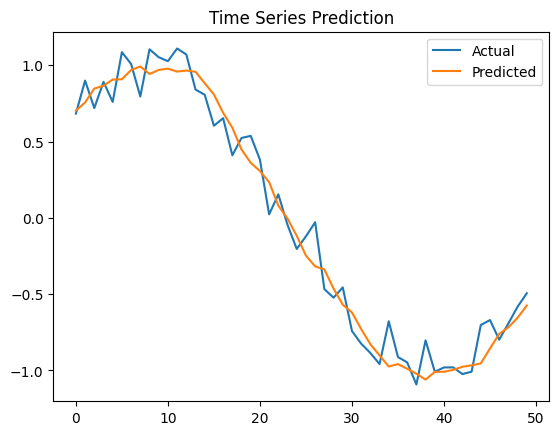

In [12]:
# Run training and evaluation
train_model()
evaluate_model()